# Re label Dataset

In [1]:
import os
import pandas as pd

LABEL_DIR = r"E:\Dataset Ta\DATASET\DAISEE\Labels"
OUTPUT_RELABEL = r"E:\Dataset Ta\Output_Relabel"

In [2]:
def get_relabel(row):

    engagement = row["Engagement"]
    confusion = row["Confusion"]

    if engagement == 0:
        return 0

    if engagement == 1 and confusion in [0, 3]:
        return 0

    return 1

In [3]:

os.makedirs(OUTPUT_RELABEL, exist_ok=True)

summary = []

for s in ["Train", "Validation", "Test"]:

    df = pd.read_csv(
        os.path.join(LABEL_DIR, f"{s}Labels.csv")
    )

    df.columns = [c.strip() for c in df.columns]

    df["NewLabel"] = df.apply(get_relabel, axis=1)

    # simpan masing-masing split
    df.to_csv(
        os.path.join(
            OUTPUT_RELABEL,
            f"{s}_Relabel.csv"
        ),
        index=False
    )

    summary.append([
        s,
        (df["NewLabel"]==0).sum(),
        (df["NewLabel"]==1).sum(),
        len(df)
    ])

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Dataset",
        "Disengaged",
        "Engaged",
        "Total"
    ]
)

summary_df.to_csv(
    os.path.join(
        OUTPUT_RELABEL,
        "Distribusi_Setelah_Relabel.csv"
    ),
    index=False
)

print(summary_df)

      Dataset  Disengaged  Engaged  Total
0       Train         148     5210   5358
1  Validation         104     1325   1429
2        Test          52     1732   1784


In [4]:
print(df["Engagement"].value_counts().sort_index())
print(df["Confusion"].value_counts().sort_index())
print(df["NewLabel"].value_counts())

Engagement
0      4
1     84
2    882
3    814
Name: count, dtype: int64
Confusion
0    1200
1     427
2     136
3      21
Name: count, dtype: int64
NewLabel
1    1732
0      52
Name: count, dtype: int64


# video to gambar

In [1]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

In [2]:
BASE_VIDEO_DIR = r"F:\Dataset Ta\DATASET\DAISEE\DataSet"
RELABEL_DIR = r"F:\Dataset Ta\Output_Relabel"
OUTPUT_DIR = r"F:\Dataset Ta\Output_Faces_ViT"
MODEL_DIR = r"F:\Dataset Ta\Models"

In [7]:
net = cv2.dnn.readNetFromCaffe(
    os.path.join(MODEL_DIR, "deploy.prototxt"),
    os.path.join(MODEL_DIR, "res10_300x300_ssd_iter_140000.caffemodel")
)

In [ ]:
print("Membuat index video...")
video_index = {}

for root, _, files in os.walk(BASE_VIDEO_DIR):

    for f in files:

        if f.lower().endswith((".avi", ".mp4")):
            clip = os.path.splitext(f)[0]
            video_index[clip] = os.path.join(root, f)

print(f"Total video ditemukan : {len(video_index)}")

# =========================================================
# PROSES PER SPLIT
# =========================================================

for split in ["Train", "Validation", "Test"]:

    print(f"\n========== {split} ==========")

    csv_path = os.path.join(
        RELABEL_DIR,
        f"{split}_Relabel.csv"
    )

    df = pd.read_csv(csv_path)

    df.columns = [c.strip() for c in df.columns]

    total_video = 0
    failed_video = 0
    saved_faces = 0

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=split
    ):

        clip_id = (
            str(row["ClipID"])
            .replace(".avi","")
            .replace(".mp4","")
        )

        label = int(row["NewLabel"])

        if clip_id not in video_index:
            failed_video += 1
            continue

        video_path = video_index[clip_id]
        total_video += 1

        save_dir = os.path.join(
            OUTPUT_DIR,
            split.lower(),
            str(label)
        )

        os.makedirs(save_dir, exist_ok=True)
        cap = cv2.VideoCapture(video_path)
        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames <= 0:
            cap.release()
            continue

        # =====================================================
        # AMBIL MAKSIMAL 10 FRAME MERATA
        # =====================================================

        frame_positions = np.linspace(
            0,
            total_frames - 1,
            10,
            dtype=int
        )

        for idx, frame_no in enumerate(frame_positions):

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                frame_no
            )

            ret, frame = cap.read()

            if not ret:
                continue

            h, w = frame.shape[:2]
            blob = cv2.dnn.blobFromImage(
                frame,
                1.0,
                (300,300),
                (104.0,177.0,123.0)
            )

            net.setInput(blob)
            detections = net.forward()

            best_face = None
            best_conf = 0

            for i in range(detections.shape[2]):
                confidence = detections[0,0,i,2]

                if confidence > 0.5 and confidence > best_conf:
                    box = detections[
                        0,
                        0,
                        i,
                        3:7
                    ] * np.array([w,h,w,h])

                    x1,y1,x2,y2 = box.astype(int)

                    x1 = max(0,x1)
                    y1 = max(0,y1)
                    x2 = min(w,x2)
                    y2 = min(h,y2)

                    face = frame[
                        y1:y2,
                        x1:x2
                    ]

                    if face.size > 0:

                        best_face = face
                        best_conf = confidence

            if best_face is not None:
                filename = (
                    f"{clip_id}_frame{idx+1}.jpg"
                )

                cv2.imwrite(
                    os.path.join(
                        save_dir,
                        filename
                    ),
                    best_face
                )
                saved_faces += 1

        cap.release()

    print(f"Video berhasil diproses : {total_video}")
    print(f"Video gagal            : {failed_video}")
    print(f"Total wajah tersimpan  : {saved_faces}")

print("\n======================================")
print("Face Extraction selesai.")
print("======================================")

Membuat index video...
Total video ditemukan : 9067

========== Train ==========


Train: 100%|██████████| 5358/5358 [1:04:45<00:00,  1.38it/s] 


Video berhasil diproses : 5357
Video gagal            : 1
Total wajah tersimpan  : 53567

========== Validation ==========


Validation: 100%|██████████| 1429/1429 [17:43<00:00,  1.34it/s]


Video berhasil diproses : 1429
Video gagal            : 0
Total wajah tersimpan  : 14286

========== Test ==========


Test: 100%|██████████| 1784/1784 [36:13<00:00,  1.22s/it]  

Video berhasil diproses : 1784
Video gagal            : 0
Total wajah tersimpan  : 17833

Face Extraction selesai.


In [ ]:
import os

BASE = r"E:\Dataset Ta\Output_Faces_ViT"

stats = []

for subset in ["train","validation","test"]:

    for label in ["0","1"]:
        path = os.path.join(BASE, subset, label)
        total = len([
            f for f in os.listdir(path)
            if f.endswith(".jpg")
        ])

        stats.append([subset,label,total])

for s in stats:
    print(s)

['train', '0', 1480]
['train', '1', 52087]
['validation', '0', 1037]
['validation', '1', 13249]
['test', '0', 520]
['test', '1', 17313]


### cek ukuran gambar dan contoh wajah

In [ ]:
import os
import cv2
from collections import Counter

IMAGE_DIR = r"E:\Dataset Ta\Output_Faces_ViT"

size_counter = Counter()
total_images = 0
failed_images = 0

widths = []
heights = []

for root, _, files in os.walk(IMAGE_DIR):

    for file in files:

        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is None:
                failed_images += 1
                continue

            h, w = img.shape[:2]

            widths.append(w)
            heights.append(h)
            
            size_counter[(w, h)] += 1
            total_images += 1

print("\n========== DISTRIBUSI UKURAN HASIL CROPPING ==========")

print(f"Total gambar   : {total_images}")
print(f"Gagal dibaca   : {failed_images}")
print(f"Ukuran unik    : {len(size_counter)}")

print(f"Lebar minimum  : {min(widths)}")
print(f"Lebar maksimum : {max(widths)}")

print(f"Tinggi minimum : {min(heights)}")
print(f"Tinggi maksimum: {max(heights)}")

print()

for (w, h), count in size_counter.most_common():

    print(f"{w} x {h} : {count}")


========== DISTRIBUSI UKURAN HASIL CROPPING ==========
Total gambar   : 85686
Gagal dibaca   : 0
Ukuran unik    : 7971
Lebar minimum  : 40
Lebar maksimum : 354
Tinggi minimum : 57
Tinggi maksimum: 426

118 x 158 : 158
117 x 158 : 155
117 x 157 : 149
119 x 156 : 124
132 x 176 : 123
117 x 159 : 121
119 x 159 : 119
109 x 146 : 119
119 x 157 : 117
118 x 157 : 116
117 x 156 : 116
118 x 156 : 116
130 x 177 : 115
119 x 158 : 114
116 x 158 : 114
109 x 141 : 112
118 x 159 : 110
119 x 161 : 103
117 x 154 : 103
109 x 143 : 103
116 x 157 : 102
120 x 160 : 102
109 x 142 : 101
116 x 159 : 100
111 x 146 : 99
121 x 157 : 98
118 x 155 : 98
110 x 146 : 98
118 x 160 : 96
104 x 131 : 96
130 x 176 : 96
131 x 176 : 96
120 x 157 : 96
105 x 142 : 96
117 x 155 : 95
110 x 141 : 95
109 x 145 : 95
118 x 162 : 94
110 x 145 : 94
104 x 130 : 93
123 x 158 : 93
131 x 177 : 93
113 x 149 : 93
108 x 147 : 93
121 x 159 : 91
121 x 160 : 91
110 x 142 : 91
119 x 155 : 90
120 x 159 : 90
119 x 154 : 89
110 x 147 : 89
131 x 17

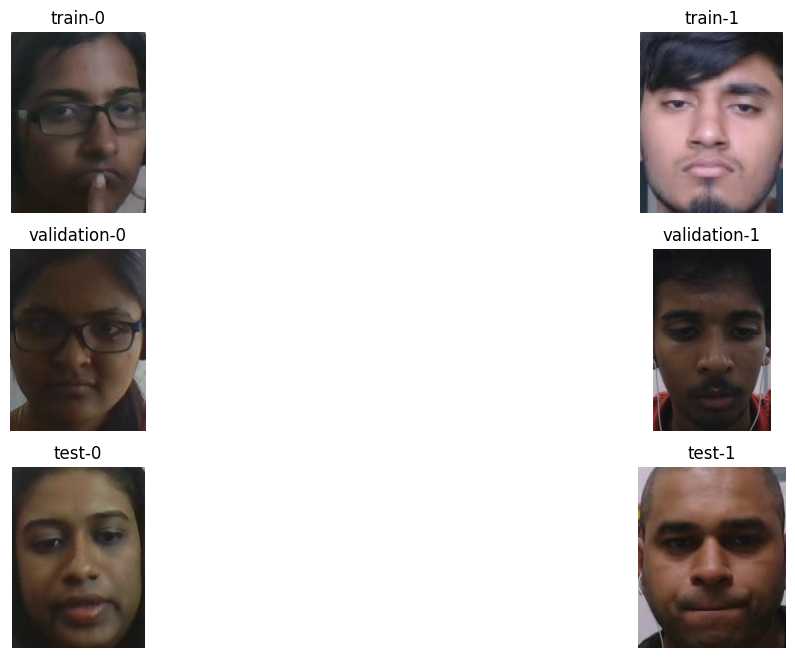

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
import random

BASE = r"E:\Dataset Ta\Output_Faces_ViT"

plt.figure(figsize=(15,8))

i = 1

for subset in ["train","validation","test"]:

    for label in ["0","1"]:
        folder = os.path.join(BASE,subset,label)
        file = random.choice(os.listdir(folder))
        img = cv2.imread(
            os.path.join(folder,file)
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(3,2,i)
        plt.imshow(img)
        plt.title(f"{subset}-{label}")
        plt.axis("off")

        i += 1

plt.show()

## resize

In [18]:
import os
import cv2
import shutil

In [19]:
INPUT_DIR = r"E:\Dataset Ta\Output_Faces_ViT"
OUTPUT_DIR = r"E:\Dataset Ta\Output_Faces_ViT_224"
TARGET_SIZE = (224, 224)

In [ ]:


# =========================================================
# HAPUS OUTPUT LAMA
# =========================================================

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Mulai proses resize...\n")

total_images = 0

# =========================================================
# RESIZE
# =========================================================

for root, dirs, files in os.walk(INPUT_DIR):

    relative = os.path.relpath(root, INPUT_DIR)

    save_dir = os.path.join(
        OUTPUT_DIR,
        relative
    )

    os.makedirs(save_dir, exist_ok=True)

    for file in files:

        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(root, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        resized = cv2.resize(
            img,
            TARGET_SIZE,
            interpolation=cv2.INTER_AREA
        )

        cv2.imwrite(
            os.path.join(save_dir, file),
            resized
        )

        total_images += 1

        if total_images % 1000 == 0:
            print(f"{total_images} gambar selesai...")

print("\n===================================")
print("Resize selesai")
print(f"Total gambar : {total_images}")
print("Ukuran akhir : 224 x 224")
print("Folder output:")
print(OUTPUT_DIR)
print("===================================")

Mulai proses resize...

1000 gambar selesai...
2000 gambar selesai...
3000 gambar selesai...
4000 gambar selesai...
5000 gambar selesai...
6000 gambar selesai...
7000 gambar selesai...
8000 gambar selesai...
9000 gambar selesai...
10000 gambar selesai...
11000 gambar selesai...
12000 gambar selesai...
13000 gambar selesai...
14000 gambar selesai...
15000 gambar selesai...
16000 gambar selesai...
17000 gambar selesai...
18000 gambar selesai...
19000 gambar selesai...
20000 gambar selesai...
21000 gambar selesai...
22000 gambar selesai...
23000 gambar selesai...
24000 gambar selesai...
25000 gambar selesai...
26000 gambar selesai...
27000 gambar selesai...
28000 gambar selesai...
29000 gambar selesai...
30000 gambar selesai...
31000 gambar selesai...
32000 gambar selesai...
33000 gambar selesai...
34000 gambar selesai...
35000 gambar selesai...
36000 gambar selesai...
37000 gambar selesai...
38000 gambar selesai...
39000 gambar selesai...
40000 gambar selesai...
41000 gambar selesai...
4

In [27]:
import os
import pandas as pd


LABEL_DIR = r"F:\Dataset Ta\DATASET\DAISEE\Labels"

# ==========================================
# DISTRIBUSI SETELAH PELABELAN ULANG
# ==========================================

stats = []

for subset in ["Train", "Validation", "Test"]:

    df = pd.read_csv(
        os.path.join(LABEL_DIR, f"{subset}Labels.csv")
    )

    df.columns = [c.strip() for c in df.columns]

    # Relabel sesuai aturan penelitian
    df["NewLabel"] = df.apply(get_relabel, axis=1)

    disengaged = (df["NewLabel"] == 0).sum()
    engaged = (df["NewLabel"] == 1).sum()
    total = len(df)

    stats.append([
        subset,
        disengaged,
        engaged,
        total
    ])

result = pd.DataFrame(
    stats,
    columns=[
        "Dataset",
        "Disengaged",
        "Engaged",
        "Total"
    ]
)

print(result)

      Dataset  Disengaged  Engaged  Total
0       Train         148     5210   5358
1  Validation         104     1325   1429
2        Test          52     1732   1784


# cek 

NOTE: path nya beda dikarenakan menggunakan harddisk jadi kadang  terdeteksi F: dan kadang E:

In [7]:
from pathlib import Path
import os
import pandas as pd
# ===============================
# DATASET VIDEO RAW
# ===============================
BASE_VIDEO_DIR = Path(r"F:\Dataset Ta\DATASET\DAISEE\DataSet")
# ===============================
# CSV ASLI DAISEE
# ===============================
ORIGINAL_LABEL_DIR = Path(r"F:\Dataset Ta\DATASET\DAISEE\Labels")
TRAIN_ORIGINAL = ORIGINAL_LABEL_DIR / "TrainLabels.csv"
VAL_ORIGINAL   = ORIGINAL_LABEL_DIR / "ValidationLabels.csv"
TEST_ORIGINAL  = ORIGINAL_LABEL_DIR / "TestLabels.csv"
# ==============================
# CSV HASIL RELABEL (saya pindahin manual ke situ path nya)
# ===============================
RELABEL_DIR = Path(r"F:\Dataset Ta\cadangan\cadangan major\Output_Relabel")
TRAIN_RELABEL = RELABEL_DIR / "Train_Relabel.csv"
VAL_RELABEL   = RELABEL_DIR / "Validation_Relabel.csv"
TEST_RELABEL  = RELABEL_DIR / "Test_Relabel.csv"
# ===============================
# HASIL EKSTRAKSI FRAME
# ===============================
OUTPUT_DIR = Path(r"F:\Dataset Ta\cadangan\cadangan major\Output_Faces_ViT_224")
TRAIN_FRAME = OUTPUT_DIR / "train"
VAL_FRAME   = OUTPUT_DIR / "validation"
TEST_FRAME  = OUTPUT_DIR / "test"

In [ ]:
from collections import defaultdict
import os

print("="*70)
print("AUDIT DISTRIBUSI FRAME / CLIP ANTAR SPLIT")
print("="*70)

clip_split = defaultdict(set)
clip_count = defaultdict(set)
frame_count = defaultdict(int)

folders = {
    "Train": TRAIN_FRAME,
    "Validation": VAL_FRAME,
    "Test": TEST_FRAME
}

for split, folder in folders.items():
    for root, dirs, files in os.walk(folder):
        for f in files:
            if not f.lower().endswith(".jpg"):
                continue

            frame_count[split] += 1
            clip = f.split("_frame")[0]
            clip_split[clip].add(split)
            clip_count[split].add(clip)

problem = False
problem_clip = []

for clip, splits in clip_split.items():

    if len(splits) > 1:
        problem = True
        problem_clip.append((clip, splits))

print("\n" + "="*70)
print("RINGKASAN DISTRIBUSI")
print("="*70)

total_clip = sum(len(v) for v in clip_count.values())
total_frame = sum(frame_count.values())

for split in folders.keys():

    print(f"{split:12}")
    print(f"   Clip  : {len(clip_count[split])}")
    print(f"   Frame : {frame_count[split]}")

print("-"*70)
print(f"TOTAL CLIP   : {total_clip}")
print(f"TOTAL FRAME  : {total_frame}")

print("-"*70)

if not problem:

    print("Clip overlap : 0")
    print("Persentase   : 0.0000%")
    print("\n✅ Semua clip hanya berada pada satu split.")

else:

    print(f"Clip overlap : {len(problem_clip)}")
    print(f"Persentase   : {(len(problem_clip)/len(clip_split))*100:.4f}%")
    print("\nDaftar Clip yang overlap:")

    for clip, splits in problem_clip:
        print(f"{clip} -> {splits}")

AUDIT DISTRIBUSI FRAME / CLIP ANTAR SPLIT

RINGKASAN DISTRIBUSI
Train       
   Clip  : 5357
   Frame : 53567
Validation  
   Clip  : 1429
   Frame : 14286
Test        
   Clip  : 1784
   Frame : 17833
----------------------------------------------------------------------
TOTAL CLIP   : 8570
TOTAL FRAME  : 85686
----------------------------------------------------------------------
Clip overlap : 0
Persentase   : 0.0000%

✅ Semua clip hanya berada pada satu split.


In [8]:
def count_media_files(root_dir, exts):
    root_dir = os.path.abspath(root_dir)
    if not os.path.isdir(root_dir):
        return 0

    count = 0
    for root, _, files in os.walk(root_dir):
        for f in files:
            if os.path.splitext(f)[1].lower() in exts:
                count += 1
    return count


# 1) Hitung jumlah raw video per split
raw_video_counts = {}
for split in ["Train", "Validation", "Test"]:
    split_dir = os.path.join(str(BASE_VIDEO_DIR), split)
    raw_video_counts[split] = count_media_files(split_dir, {".avi", ".mp4"})


# 2) Hitung jumlah baris relabel per split
relabel_counts = {}
for split in ["Train", "Validation", "Test"]:
    csv_path = os.path.join(str(RELABEL_DIR), f"{split}_Relabel.csv")
    if os.path.isfile(csv_path):
        relabel_counts[split] = len(pd.read_csv(csv_path))
    else:
        relabel_counts[split] = 0


# 3) Hitung jumlah image hasil ekstraksi / resize per split
image_counts = {}
unique_clips = {}
for subset in ["train", "validation", "test"]:
    split_dir = os.path.join(OUTPUT_DIR, subset)
    image_counts[subset] = count_media_files(split_dir, {".jpg", ".jpeg", ".png"})

    clip_ids = set()
    if os.path.isdir(split_dir):
        for root, _, files in os.walk(split_dir):
            for f in files:
                if os.path.splitext(f)[1].lower() in {".jpg", ".jpeg", ".png"}:
                    clip_ids.add(f.lower().split("_frame")[0].strip())
    unique_clips[subset] = len(clip_ids)


# 4) Hitung distribusi label akhir per subset
image_class_distribution = []
for subset in ["train", "validation", "test"]:
    for label in ["0", "1"]:
        label_dir = os.path.join(OUTPUT_DIR, subset, label)
        count = count_media_files(label_dir, {".jpg", ".jpeg", ".png"})
        image_class_distribution.append([subset, label, count])


# ==========================================================
# RINGKASAN PIPELINE
# ==========================================================

summary_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Raw Video": [
        raw_video_counts["Train"],
        raw_video_counts["Validation"],
        raw_video_counts["Test"]
    ],
    "CSV Relabel": [
        relabel_counts["Train"],
        relabel_counts["Validation"],
        relabel_counts["Test"]
    ],
    "Extracted Images": [
        image_counts["train"],
        image_counts["validation"],
        image_counts["test"]
    ],
    "Unique Clip": [
        unique_clips["train"],
        unique_clips["validation"],
        unique_clips["test"]
    ]
})

summary_df.loc["Total"] = [
    "TOTAL",
    summary_df["Raw Video"].sum(),
    summary_df["CSV Relabel"].sum(),
    summary_df["Extracted Images"].sum(),
    summary_df["Unique Clip"].sum()
]

print("\n" + "="*80)
print("PIPELINE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))


# ==========================================================
# DISTRIBUSI IMAGE PER LABEL
# ==========================================================

dist_df = pd.DataFrame(image_class_distribution,
                       columns=["Subset", "Label", "Image_Count"])

dist_pivot = dist_df.pivot(
    index="Subset",
    columns="Label",
    values="Image_Count"
).fillna(0).astype(int)

dist_pivot.columns = ["Disengaged (0)", "Engaged (1)"]

dist_pivot["Total"] = (
    dist_pivot["Disengaged (0)"] +
    dist_pivot["Engaged (1)"]
)

dist_pivot.loc["TOTAL"] = dist_pivot.sum()

print("\n" + "="*80)
print("FINAL IMAGE DISTRIBUTION")
print("="*80)
print(dist_pivot)


# ==========================================================
# RASIO KELAS
# ==========================================================

ratio_df = dist_pivot.iloc[:-1].copy()

ratio_df["Disengaged (%)"] = (
    ratio_df["Disengaged (0)"] /
    ratio_df["Total"] * 100
).round(2)

ratio_df["Engaged (%)"] = (
    ratio_df["Engaged (1)"] /
    ratio_df["Total"] * 100
).round(2)

print("\n" + "="*80)
print("CLASS RATIO")
print("="*80)
print(ratio_df[[
    "Disengaged (%)",
    "Engaged (%)"
]])


PIPELINE SUMMARY
     Split  Raw Video  CSV Relabel  Extracted Images  Unique Clip
     Train       5481         5358             53567         5357
Validation       1720         1429             14286         1429
      Test       1866         1784             17833         1784
     TOTAL       9067         8571             85686         8570

FINAL IMAGE DISTRIBUTION
            Disengaged (0)  Engaged (1)  Total
Subset                                        
test                   520        17313  17833
train                 1480        52087  53567
validation            1037        13249  14286
TOTAL                 3037        82649  85686

CLASS RATIO
            Disengaged (%)  Engaged (%)
Subset                                 
test                  2.92        97.08
train                 2.76        97.24
validation            7.26        92.74


In [ ]:
import os

print("="*60)
print("JUMLAH FRAME")
print("="*60)

for split,folder in folders.items():

    total=0

    for root,dirs,files in os.walk(folder):
        total+=len([f for f in files if f.endswith(".jpg")])
    print(split,total)

JUMLAH FRAME
Train 53567
Validation 14286
Test 17833


In [3]:
import os

path_to_check = r"F:\Dataset Ta\cadangan\cadangan major\Output_Faces_ViT_224"
total_images = 0

for root_dir, _, files in os.walk(path_to_check):
    total_images += len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))])

print(f"Total citra di {path_to_check}: {total_images}")

Total citra di F:\Dataset Ta\cadangan\cadangan major\Output_Faces_ViT_224: 85686
